# Train Multitask: Face Mask + People Counting

Notebook ini training 1 model YOLO26m yang sekaligus deteksi face mask + orang. Dataset gabungan dari face_mask + people_counting, total 4 kelas:

- `0 = improper_mask`
- `1 = mask`
- `2 = no_mask`
- `3 = person`

## Catatan Penting Sebelum Mulai

Dataset gabungan ini punya **label noise** yang nggak bisa dihindari:

- Image dari `face_mask` cuma punya label wajah — nggak ada label `person`, walau orangnya jelas kelihatan.
- Image dari `people_counting` cuma punya label `person` — nggak ada label wajah, walau wajahnya kelihatan.

Akibatnya model dapat sinyal nggak konsisten saat training. Hasil yang biasa terjadi:

- Face mask: lumayan, tapi kalah dari single-task model.
- People counting: rentan undercount sistematis.

**Pendekatan yang lebih bersih: train 2 model terpisah** (lihat `face_mask/01_train.ipynb` dan `people_counting/01_train.ipynb`). Notebook ini tetap disimpan sebagai eksperimen / referensi — buat tau seberapa parah trade-off-nya.

## Alur

1. Setup
2. Bikin dataset gabungan (4 kelas)
3. Cek distribusi
4. Training
5. Load run terakhir
6. Evaluasi face mask
7. Evaluasi people counting
8. Visualisasi gabungan


In [1]:
%matplotlib inline

from __future__ import annotations

import contextlib
import os
import math
import random
import shutil
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

FACE_DATASET_DIR   = RESEARCH_DIR / "datasets" / "interim" / "face_mask_cctv_split"
PEOPLE_DATASET_DIR = RESEARCH_DIR / "datasets" / "raw" / "people_counting"
MERGED_DATASET_DIR = RESEARCH_DIR / "datasets" / "processed" / "face_mask_person_multitask"
DATA_YAML          = MERGED_DATASET_DIR / "data.yaml"

BASE_MODEL    = AI_DIR / "models" / "yolo26m.pt"
RUNS_DIR      = RESEARCH_DIR / "runs" / "detect"
ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "multitask"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME       = "multitask_yolo26m"
SEED           = 42
TARGET_CLASSES = ["improper_mask", "mask", "no_mask", "person"]
FACE_CLASS_MAP = {0: 0, 1: 1, 2: 2}
PERSON_NAME_HINTS = {
    "person", "people", "pedestrian", "pedestrians",
    "persona", "pessoa", "persons",
}

for p in [BASE_MODEL, FACE_DATASET_DIR, PEOPLE_DATASET_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Nggak ketemu: {p}")
print("Face dataset:", FACE_DATASET_DIR)
print("People dataset:", PEOPLE_DATASET_DIR)
print("Merged target:", MERGED_DATASET_DIR)

Face dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\interim\face_mask_cctv_split
People dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\people_counting
Merged target: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\face_mask_person_multitask


## Bikin Dataset Gabungan

Gabungin face_mask + people_counting jadi 1 dataset 4 kelas:

- Label face_mask di-remap: 0→0, 1→1, 2→2 (kelas wajah).
- Label person dari people_counting di-remap ke 3 (kelas non-person dari raw dibuang).

Set `OVERWRITE_MERGED = True` kalau mau rebuild.


In [2]:
OVERWRITE_MERGED = False


def _list_images(image_dir: Path) -> list[Path]:
    images: list[Path] = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        images.extend(sorted(image_dir.glob(ext)))
    return images


def _resolve_person_source_ids(people_cfg: dict) -> set[int]:
    names = people_cfg.get("names", [])
    matched = {
        i for i, n in enumerate(names)
        if str(n).strip().lower() in PERSON_NAME_HINTS
    }
    if not matched:
        raise ValueError("Nggak nemu kelas person-like di people_counting/data.yaml")
    return matched


def _remap_label_lines(label_path: Path, source: str, person_src_ids: set[int]) -> list[str]:
    if not label_path.exists():
        return []
    out: list[str] = []
    for raw in label_path.read_text(encoding="utf-8").splitlines():
        raw = raw.strip()
        if not raw:
            continue
        parts = raw.split()
        cls_id = int(parts[0])
        if source == "face":
            new = FACE_CLASS_MAP.get(cls_id)
            if new is None:
                continue
        else:
            if cls_id not in person_src_ids:
                continue
            new = 3
        out.append(" ".join([str(new)] + parts[1:]))
    return out


def build_merged_dataset() -> dict:
    if DATA_YAML.exists() and not OVERWRITE_MERGED:
        print("Merged dataset udah ada, skip rebuild:", DATA_YAML)
        return {}
    if MERGED_DATASET_DIR.exists() and OVERWRITE_MERGED:
        shutil.rmtree(MERGED_DATASET_DIR)

    face_cfg   = yaml.safe_load((FACE_DATASET_DIR / "data.yaml").read_text(encoding="utf-8"))
    people_cfg = yaml.safe_load((PEOPLE_DATASET_DIR / "data.yaml").read_text(encoding="utf-8"))
    person_src = _resolve_person_source_ids(people_cfg)
    print("Face classes:", face_cfg.get("names"))
    print("Person source IDs:", sorted(person_src))

    random.seed(SEED)
    stats: dict[str, int] = defaultdict(int)
    for split in ("train", "valid", "test"):
        samples: list[tuple[str, Path]] = []
        face_dir   = FACE_DATASET_DIR / split / "images"
        people_dir = PEOPLE_DATASET_DIR / split / "images"
        if face_dir.exists():
            samples += [("face", p) for p in _list_images(face_dir)]
        if people_dir.exists():
            samples += [("people", p) for p in _list_images(people_dir)]
        random.shuffle(samples)

        for idx, (src, img_path) in enumerate(samples):
            lbl_src = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
            mapped  = _remap_label_lines(lbl_src, src, person_src)
            if not mapped:
                continue
            stem = f"{src}_{idx:07d}"
            dst_img = MERGED_DATASET_DIR / split / "images" / f"{stem}{img_path.suffix.lower()}"
            dst_lbl = MERGED_DATASET_DIR / split / "labels" / f"{stem}.txt"
            dst_img.parent.mkdir(parents=True, exist_ok=True)
            dst_lbl.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dst_img)
            dst_lbl.write_text("\n".join(mapped) + "\n", encoding="utf-8")
            stats[f"{split}_total"] += 1
            stats[f"{split}_{src}"] += 1

    cfg = {
        "path":  str(MERGED_DATASET_DIR.resolve()),
        "train": "train/images",
        "val":   "valid/images",
        "test":  "test/images",
        "nc":    len(TARGET_CLASSES),
        "names": TARGET_CLASSES,
    }
    DATA_YAML.parent.mkdir(parents=True, exist_ok=True)
    DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
    print("Stats:", dict(stats))
    return dict(stats)


build_merged_dataset()

Merged dataset udah ada, skip rebuild: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\face_mask_person_multitask\data.yaml


{}

## Cek Distribusi Kelas

Lihat berapa label per kelas per split. Kelas `person` biasanya jauh lebih banyak karena image people_counting biasa punya 5–50+ orang per image, sedangkan face_mask cuma 1–3 wajah.


In [3]:
def count_class_distribution(split: str) -> dict[int, int]:
    counts = {0: 0, 1: 0, 2: 0, 3: 0}
    lbl_dir = MERGED_DATASET_DIR / split / "labels"
    if not lbl_dir.exists():
        return counts
    for lbl in lbl_dir.glob("*.txt"):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
    return counts


dist = {split: count_class_distribution(split) for split in ("train", "valid", "test")}
dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = TARGET_CLASSES
print(dist_df.to_string())

               train  valid  test
improper_mask   2393    663   318
mask            1833    539   264
no_mask         1804    513   260
person         78629  10040  2679


## Training

Set `RUN_TRAINING = True` kalau mau training ulang.


In [4]:
RUN_TRAINING = False

TRAIN_CFG = {
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "workers": 4,
    "patience": 20,
    "seed": SEED,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / "models"):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print("Training kelar:", result.save_dir)
else:
    print("Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.")

Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.


## Load Run Terakhir


In [5]:
def find_latest_run(prefix: str) -> Path:
    candidates = [
        d for d in RUNS_DIR.glob(f"{prefix}*")
        if d.is_dir() and (d / "weights" / "best.pt").exists()
    ]
    if not candidates:
        raise FileNotFoundError(f"Belum ada run dengan prefix '{prefix}' di {RUNS_DIR}")
    return max(candidates, key=lambda d: d.stat().st_mtime)


run_dir     = find_latest_run(RUN_NAME)
best_pt     = run_dir / "weights" / "best.pt"
results_csv = run_dir / "results.csv"
eval_model  = YOLO(str(best_pt))

print("Run dir:", run_dir)
print("Best weights:", best_pt)
print("Kelas:", eval_model.names)

Run dir: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\multitask_yolo26m
Best weights: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\multitask_yolo26m\weights\best.pt
Kelas: {0: 'improper_mask', 1: 'mask', 2: 'no_mask', 3: 'person'}


## Evaluasi Face Mask

Validate di dataset face_mask asli (cuma 3 kelas wajah, kelas person di-ignore).


In [6]:
val = eval_model.val(
    data=str(FACE_DATASET_DIR / "data.yaml"),
    imgsz=640, conf=0.25, verbose=False,
)
face_metrics = {
    "mAP50":     round(float(val.box.map50), 3),
    "mAP50-95":  round(float(val.box.map),   3),
    "Precision": round(float(val.box.mp),    3),
    "Recall":    round(float(val.box.mr),    3),
}
print("Face mask metrics:")
print(pd.DataFrame([face_metrics]).to_string(index=False))

Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2398.8735.1 MB/s, size: 381.6 KB)
val: Scanning C:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\interim\face_mask_cctv_split\valid\labels.cache... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 61.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.0it/s 5.5s0.2s
                   all        349       1715      0.806      0.788      0.759      0.354
Speed: 0.8ms preprocess, 11.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\detect\val22
Face mask metrics:
 mAP50  mAP50-95  Precision  Recall
 0.759     0.354      0.806   0.788


## Evaluasi People Counting

Hitung prediksi class 3 (person) vs label person di GT raw (class IDs `{7, 8, 9, 10, 41, 42, 43}` — variasi nama person-like di dataset raw). 500 image dari split test+valid.


In [7]:
PERSON_GT_CLASS_IDS  = {7, 8, 9, 10, 41, 42, 43}
PERSON_PRED_CLASS_ID = 3
MAX_IMAGES  = 500
COUNT_CONF  = 0.25
COUNT_IMGSZ = 640

count_model = YOLO(str(best_pt))


def collect_people_eval_images() -> list[Path]:
    images: list[Path] = []
    for split in ("test", "valid"):
        d = PEOPLE_DATASET_DIR / split / "images"
        if not d.exists():
            continue
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            images.extend(sorted(d.glob(ext)))
    return images


def count_gt(label_path: Path) -> int:
    if not label_path.exists():
        return 0
    n = 0
    for line in label_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if int(line.split()[0]) in PERSON_GT_CLASS_IDS:
            n += 1
    return n


def count_pred(image_path: Path) -> int:
    r = count_model.predict(str(image_path), conf=COUNT_CONF, imgsz=COUNT_IMGSZ, verbose=False, device="cpu")
    if not r or r[0].boxes is None:
        return 0
    return sum(1 for b in r[0].boxes if int(b.cls.item()) == PERSON_PRED_CLASS_ID)


images = collect_people_eval_images()
if MAX_IMAGES is not None and len(images) > MAX_IMAGES:
    images = random.Random(SEED).sample(images, MAX_IMAGES)
print("Eval images:", len(images))

rows = []
for i, img_path in enumerate(images, start=1):
    gt   = count_gt(img_path.parent.parent / "labels" / f"{img_path.stem}.txt")
    pred = count_pred(img_path)
    err  = pred - gt
    rows.append({"gt": gt, "pred": pred, "err": err, "abs_err": abs(err)})
    if i % 100 == 0:
        print(f"  {i}/{len(images)}")

count_df = pd.DataFrame(rows)
count_metrics = {
    "samples":     int(len(count_df)),
    "MAE":         round(float(count_df["abs_err"].mean()), 3),
    "RMSE":        round(float(((count_df["err"] ** 2).mean()) ** 0.5), 3),
    "exact_match": round(float((count_df["err"] == 0).mean()), 3),
    "within_1":    round(float((count_df["abs_err"] <= 1).mean()), 3),
    "bias":        round(float(count_df["err"].mean()), 3),
}
print()
print("People counting metrics:")
print(pd.DataFrame([count_metrics]).to_string(index=False))

Eval images: 500
  100/500
  200/500
  300/500
  400/500
  500/500

People counting metrics:
 samples   MAE  RMSE  exact_match  within_1   bias
     500 1.354 6.606         0.67      0.85 -0.726


## Visualisasi

Lima blok visualisasi:

1. **Training curves** — convergence check.
2. **Face mask per-class** + **confusion matrix** — kelas wajah mana yang lemah.
3. **Counting scatter + error distribution + cumulative accuracy** — performa hitungan orang.
4. **Per-density breakdown** — MAE per kelompok density.
5. **Sample prediksi** — sanity check dengan label dari kedua task sekaligus.


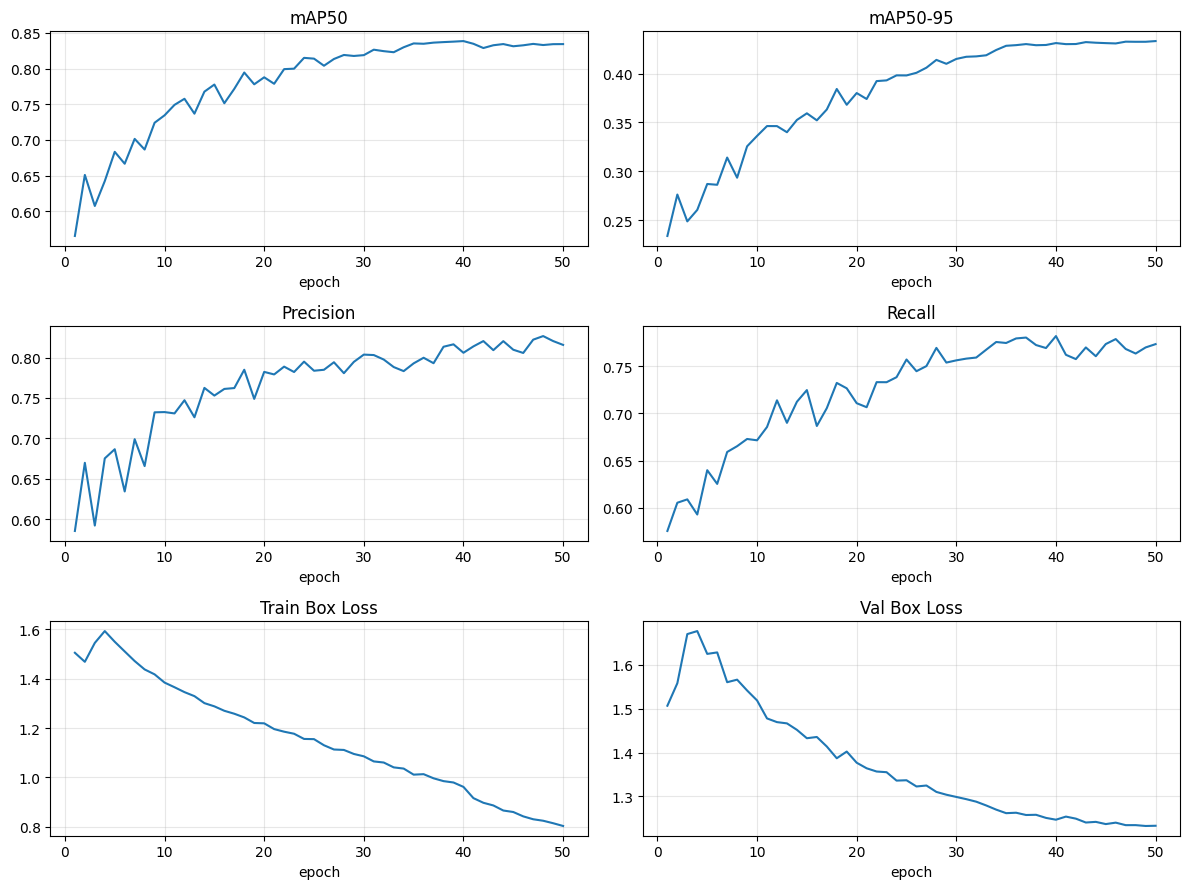

In [8]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

curves = [
    ("metrics/mAP50(B)",     "mAP50"),
    ("metrics/mAP50-95(B)",  "mAP50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("train/box_loss",       "Train Box Loss"),
    ("val/box_loss",         "Val Box Loss"),
]
available = [(c, label) for c, label in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n))
axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df["epoch"], df[col])
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Per-class metrics:
        class  Precision  Recall  mAP50  mAP50-95
improper_mask      0.747   0.855  0.818     0.400
         mask      0.831   0.701  0.689     0.320
      no_mask      0.839   0.807  0.770     0.343


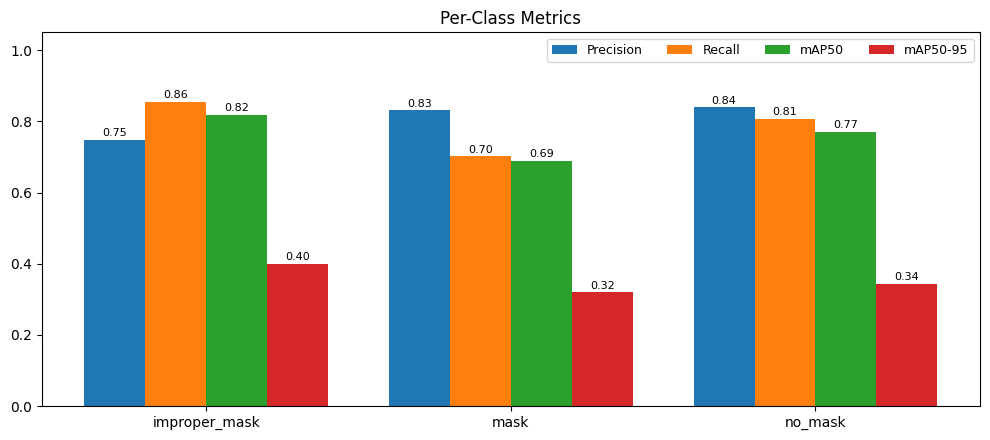

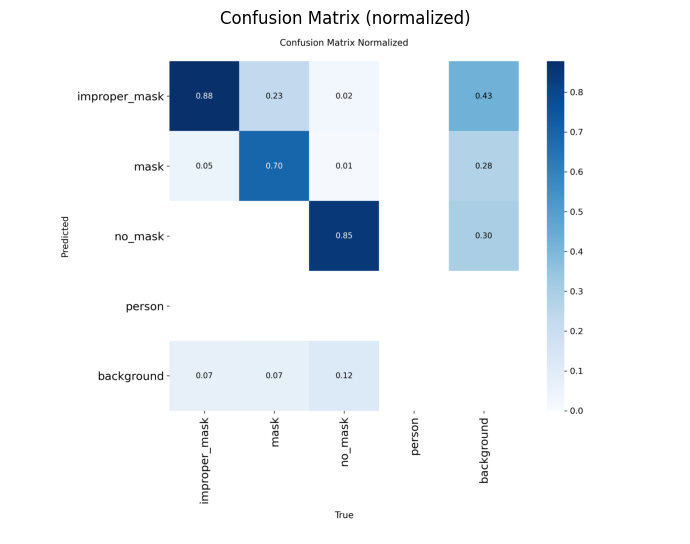

In [9]:
class_indices = val.box.ap_class_index.astype(int).tolist()
per_class = []
for i, ci in enumerate(class_indices):
    p, r, ap50, ap = val.box.class_result(i)
    per_class.append({
        "class":     val.names[ci],
        "Precision": float(p),
        "Recall":    float(r),
        "mAP50":     float(ap50),
        "mAP50-95":  float(ap),
    })
per_class_df = pd.DataFrame(per_class)
print("Per-class metrics:")
print(per_class_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
to_plot = ["Precision", "Recall", "mAP50", "mAP50-95"]
x = list(range(len(per_class_df)))
width = 0.2
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for j, m in enumerate(to_plot):
    offset = (j - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], per_class_df[m], width, label=m, color=colors[j])
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(per_class_df["class"])
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Metrics")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

cm_path = Path(val.save_dir) / "confusion_matrix_normalized.png"
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(Image.open(cm_path))
    ax.set_title("Confusion Matrix (normalized)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix nggak ketemu di:", cm_path)

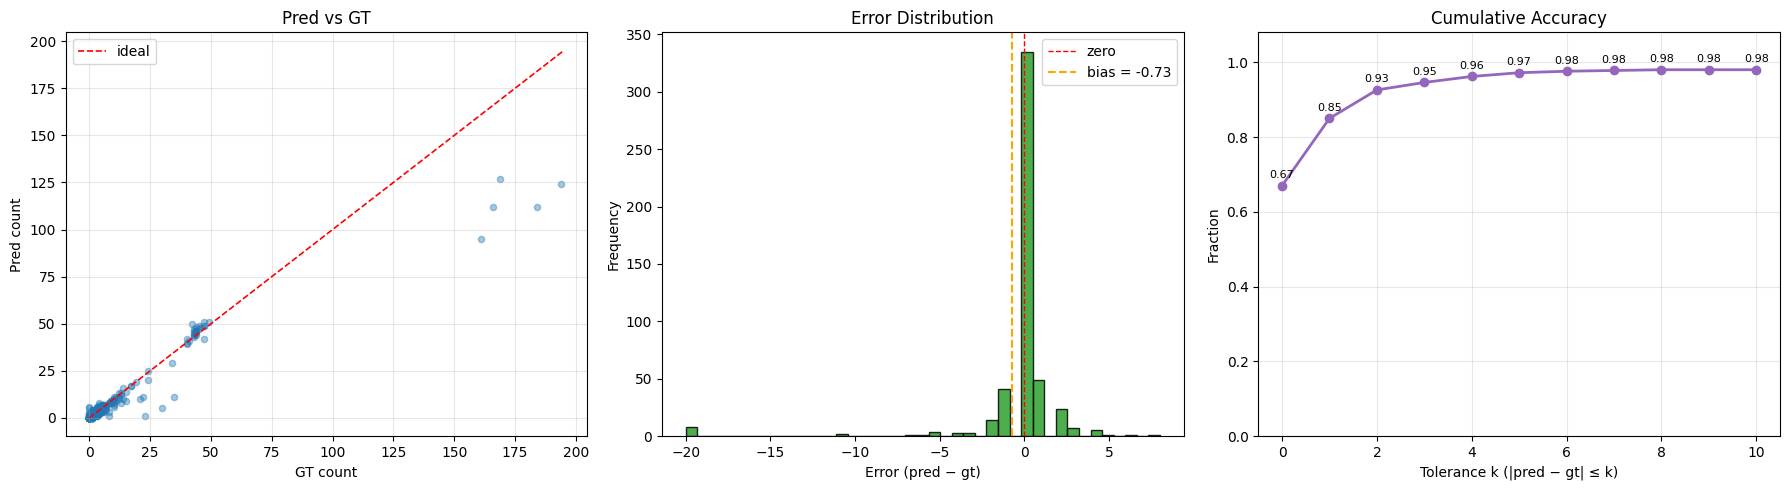

Per-density breakdown:
           n    MAE   bias
density                   
0         65   0.37   0.37
1-5      349   0.35   0.09
6-10      33   1.30  -1.12
11-20     15   1.67  -1.27
21-50     33   4.82  -1.73
50+        5  60.80 -60.80


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_v = int(max(count_df["gt"].max(), count_df["pred"].max())) + 1
axes[0].scatter(count_df["gt"], count_df["pred"], alpha=0.4, s=20, color="#1f77b4")
axes[0].plot([0, max_v], [0, max_v], "r--", linewidth=1.2, label="ideal")
axes[0].set_xlabel("GT count")
axes[0].set_ylabel("Pred count")
axes[0].set_title("Pred vs GT")
axes[0].legend()
axes[0].grid(alpha=0.3)

err_clip = count_df["err"].clip(-20, 20)
axes[1].hist(err_clip, bins=41, color="#2ca02c", edgecolor="black", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
axes[1].axvline(count_metrics["bias"], color="orange", linestyle="--",
                label=f"bias = {count_metrics['bias']:.2f}")
axes[1].set_xlabel("Error (pred − gt)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Error Distribution")
axes[1].legend()

ks = list(range(0, 11))
cum = [(count_df["abs_err"] <= k).mean() for k in ks]
axes[2].plot(ks, cum, marker="o", color="#9467bd", linewidth=2)
for k, v in zip(ks, cum):
    axes[2].text(k, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
axes[2].set_ylim(0, 1.08)
axes[2].set_xlabel("Tolerance k (|pred − gt| ≤ k)")
axes[2].set_ylabel("Fraction")
axes[2].set_title("Cumulative Accuracy")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

bins = [-1, 0, 5, 10, 20, 50, max(int(count_df["gt"].max()) + 1, 51)]
labels = ["0", "1-5", "6-10", "11-20", "21-50", "50+"]
df_bin = count_df.copy()
df_bin["density"] = pd.cut(df_bin["gt"], bins=bins, labels=labels)
summary = (
    df_bin.groupby("density", observed=True)
    .agg(n=("gt", "size"), MAE=("abs_err", "mean"), bias=("err", "mean"))
    .round(2)
)
print("Per-density breakdown:")
print(summary.to_string())

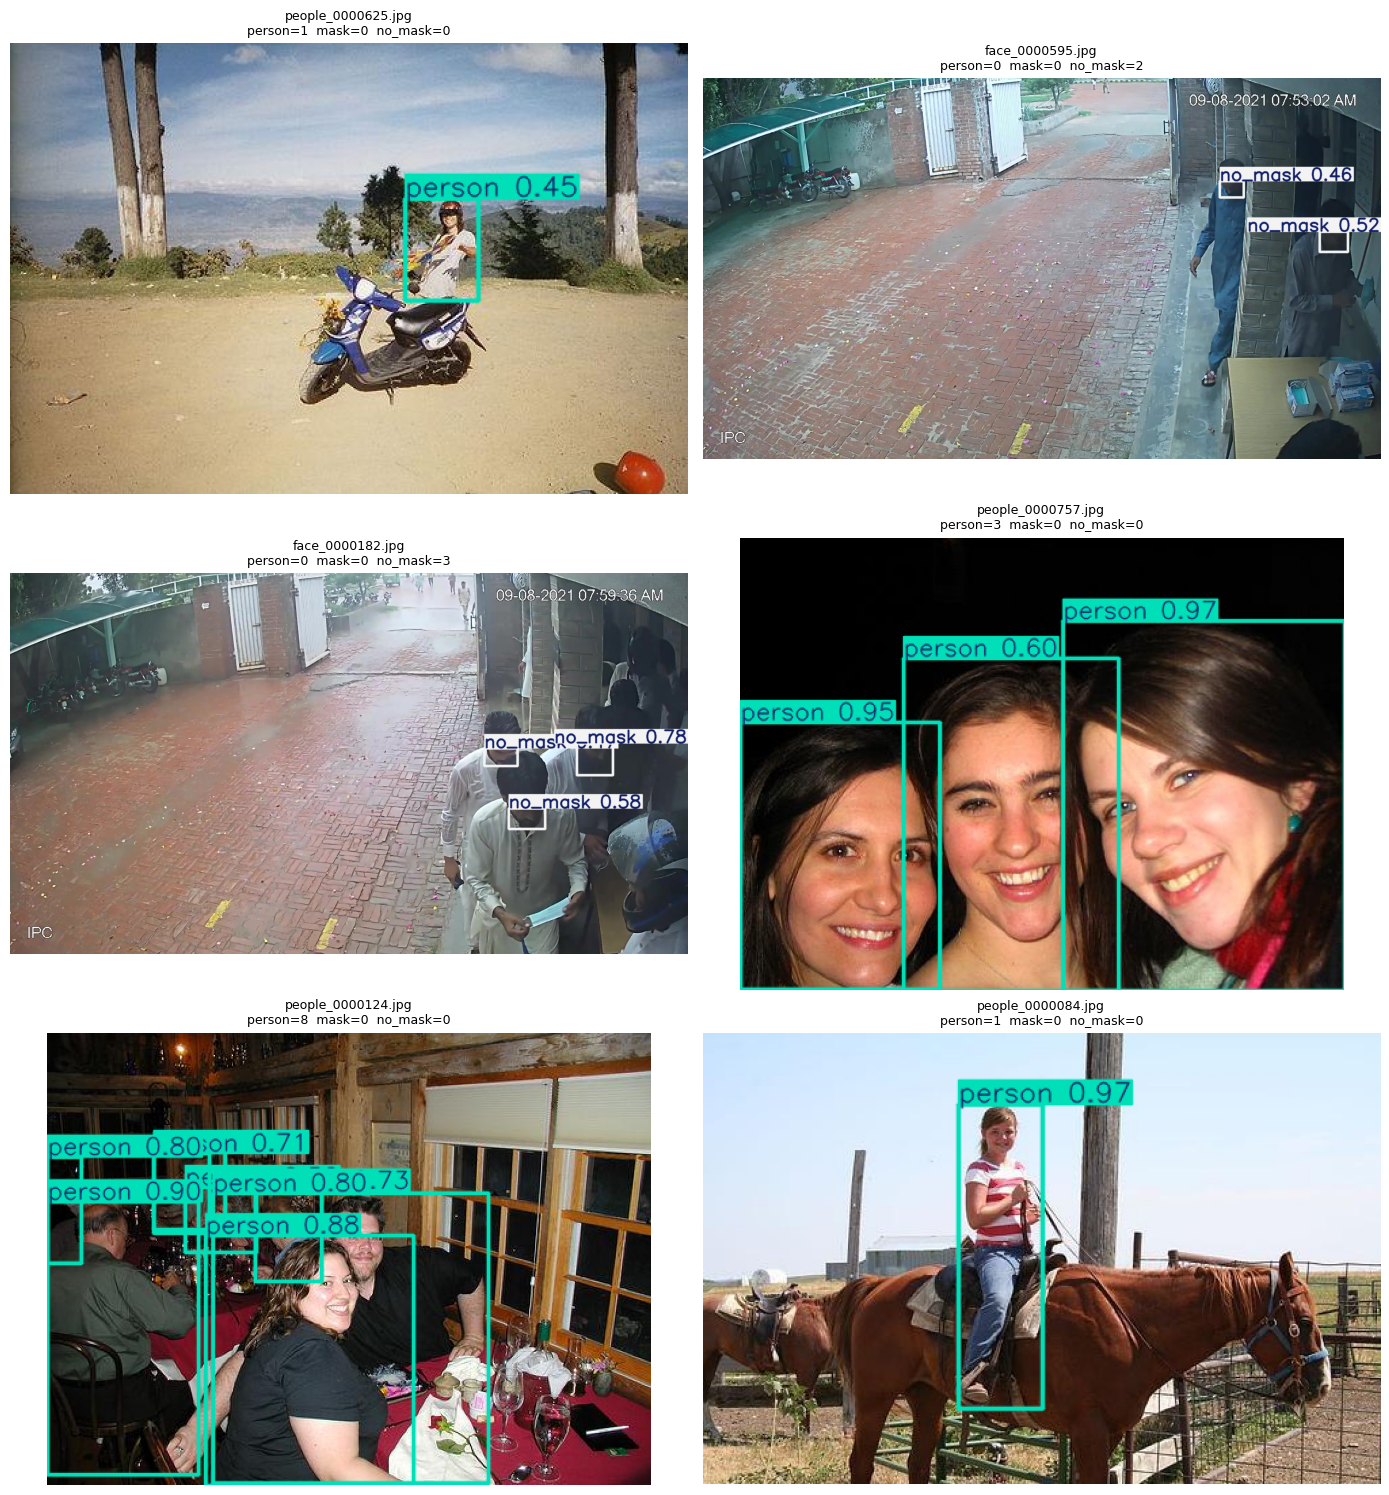

In [11]:
N_SAMPLES = 6
test_dir = MERGED_DATASET_DIR / "test" / "images"
test_images: list[Path] = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    test_images.extend(sorted(test_dir.glob(ext)))

samples = random.Random(SEED).sample(test_images, min(N_SAMPLES, len(test_images)))

cols = 2
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    r = eval_model.predict(str(img_path), conf=0.25, imgsz=640, verbose=False)[0]
    counts = {0: 0, 1: 0, 2: 0, 3: 0}
    if r.boxes is not None:
        for b in r.boxes:
            cid = int(b.cls.item())
            if cid in counts:
                counts[cid] += 1
    person_n   = counts[3]
    masked_n   = counts[0] + counts[1]
    no_mask_n  = counts[2]
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(
        f"{img_path.name}\nperson={person_n}  mask={masked_n}  no_mask={no_mask_n}",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Catatan & Perbandingan

Multitask hampir selalu lebih lemah dari single-task karena label noise yang udah dijelasin di intro. Patokan:

- **Face mask mAP50** biasanya 5 – 10% lebih rendah dari `face_mask_yolo26m` single-task.
- **People counting MAE** biasanya 1 – 3 lebih buruk karena ~50% data training (face_mask images) nggak punya label person.

Bandingin hasil notebook ini dengan:

- `face_mask/01_train.ipynb` — single-task face mask.
- `people_counting/01_train.ipynb` — single-task people counting.

Multitask cuma worth dipakai kalau:

- Resource constrained (GPU memory tight, butuh 1 model bukan 2).
- Hasil kompetitif sama dua single-task (jarang).

Kalau hasilnya jauh kalah dari single-task, tetap pakai dua model terpisah aja.
